# Plot Training Curves
This notebook parses the `outputs/logs/training_logs.txt` file and visualizes the training progress (Loss, Accuracy, Precision, Recall, F1-score, AUC).

In [1]:
%pip -q install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import matplotlib.pyplot as plt
import re
from pathlib import Path

# If running from the notebooks/ folder, hop to project root
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

# Initialize lists to store metrics
epochs = []
train_loss = []
train_acc = []
train_prec = []
train_rec = []
train_f1 = []
train_auc = []
val_loss = []
val_acc = []
val_prec = []
val_rec = []
val_f1 = []
val_auc = []

# Read the log file
log_file = project_root / "outputs" / "logs" / "training_logs.txt"
fallback_log_file = project_root / "training_logs.txt"  # legacy path
if not log_file.exists() and fallback_log_file.exists():
    log_file = fallback_log_file

if not log_file.exists():
    print(f"Error: File '{log_file}' not found.")
    print("Tip: save your terminal output as outputs/logs/training_logs.txt")
else:
    lines = log_file.read_text(encoding="utf-8", errors="ignore").splitlines()

    # Parse the file
    current_epoch = None
    current_train_metrics = {}
    
    for line in lines:
        # Extract Epoch number
        epoch_match = re.search(r'Epoch (\d+)/', line)
        if epoch_match:
            current_epoch = int(epoch_match.group(1))
            current_train_metrics = {}  # Reset for new epoch
        
        # Extract Training metrics
        if "Train - Loss:" in line and current_epoch is not None:
            try:
                loss = float(re.search(r'Loss: ([\d\.]+)', line).group(1))
                acc = float(re.search(r'Acc: ([\d\.]+)', line).group(1))
                prec = float(re.search(r'Prec: ([\d\.]+)', line).group(1))
                rec = float(re.search(r'Rec: ([\d\.]+)', line).group(1))
                f1 = float(re.search(r'F1: ([\d\.]+)', line).group(1))
                auc = float(re.search(r'AUC: ([\d\.]+)', line).group(1))
                current_train_metrics = {
                    'loss': loss,
                    'acc': acc,
                    'prec': prec,
                    'rec': rec,
                    'f1': f1,
                    'auc': auc,
                }
            except AttributeError:
                continue

        # Extract Validation metrics
        # Note: Using flexible regex for "Val - Loss" to handle variable spacing
        if re.search(r'Val\s+-\s+Loss:', line) and current_epoch is not None:
            try:
                loss = float(re.search(r'Loss: ([\d\.]+)', line).group(1))
                acc = float(re.search(r'Acc: ([\d\.]+)', line).group(1))
                prec = float(re.search(r'Prec: ([\d\.]+)', line).group(1))
                rec = float(re.search(r'Rec: ([\d\.]+)', line).group(1))
                f1 = float(re.search(r'F1: ([\d\.]+)', line).group(1))
                auc = float(re.search(r'AUC: ([\d\.]+)', line).group(1))
                
                # Only append if we have corresponding train metrics
                if current_train_metrics:
                    epochs.append(current_epoch)
                    
                    train_loss.append(current_train_metrics['loss'])
                    train_acc.append(current_train_metrics['acc'])
                    train_prec.append(current_train_metrics['prec'])
                    train_rec.append(current_train_metrics['rec'])
                    train_f1.append(current_train_metrics['f1'])
                    train_auc.append(current_train_metrics['auc'])
                    
                    val_loss.append(loss)
                    val_acc.append(acc)
                    val_prec.append(prec)
                    val_rec.append(rec)
                    val_f1.append(f1)
                    val_auc.append(auc)
                    
                    current_train_metrics = {}  # Consumed
            except AttributeError:
                continue

# Final check
if not epochs:
    print("Warning: No epochs parsed. Check if the log format matches scripts/train.py output.")

Successfully parsed 50 epochs.


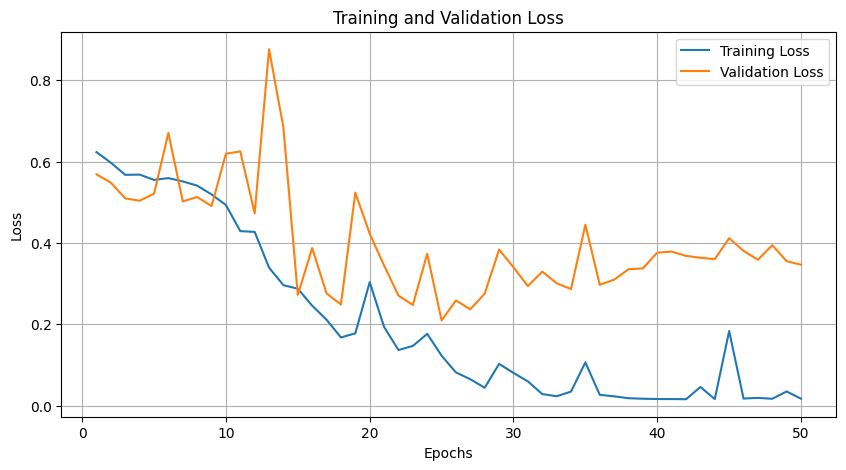

In [3]:
# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

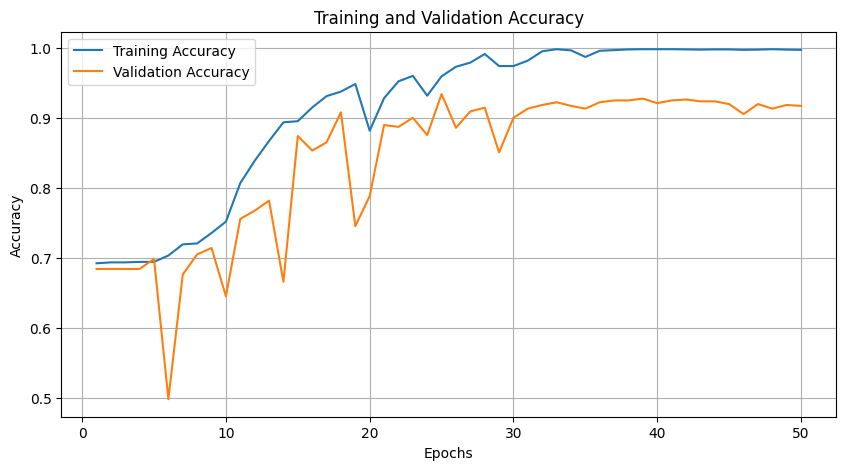

In [4]:
# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

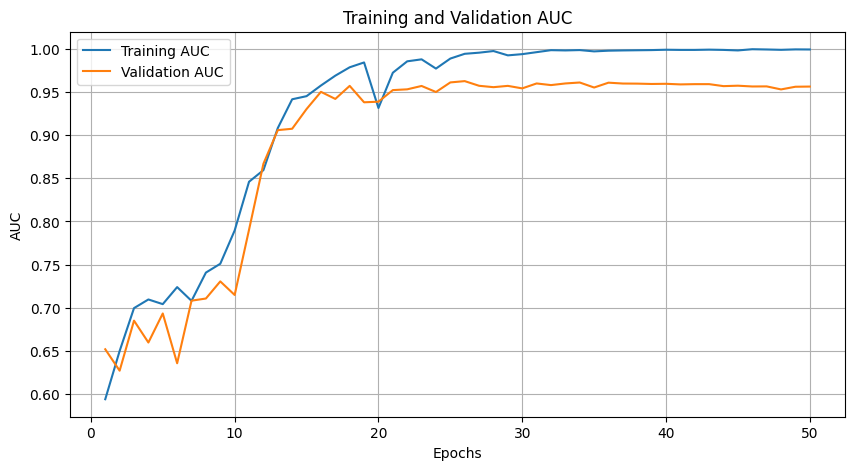

In [8]:
# Plot AUC
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_auc, label='Training AUC')
plt.plot(epochs, val_auc, label='Validation AUC')
plt.title('Training and Validation AUC')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)
plt.show()

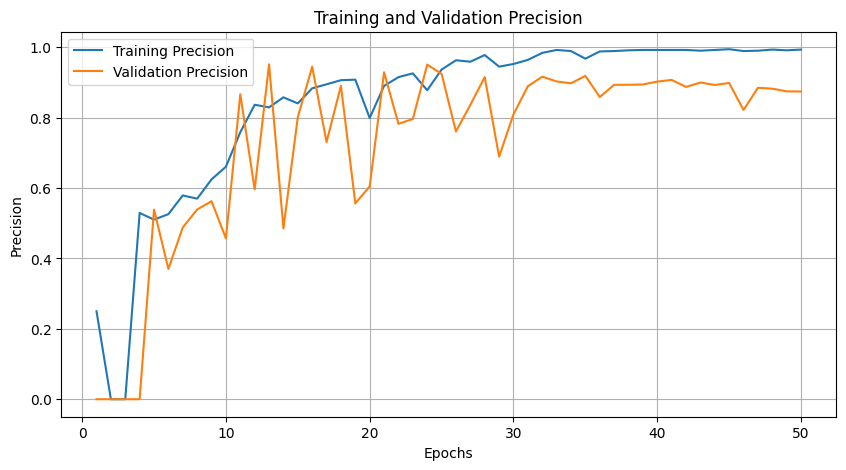

In [5]:
# Plot Precision
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_prec, label='Training Precision')
plt.plot(epochs, val_prec, label='Validation Precision')
plt.title('Training and Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)
plt.show()

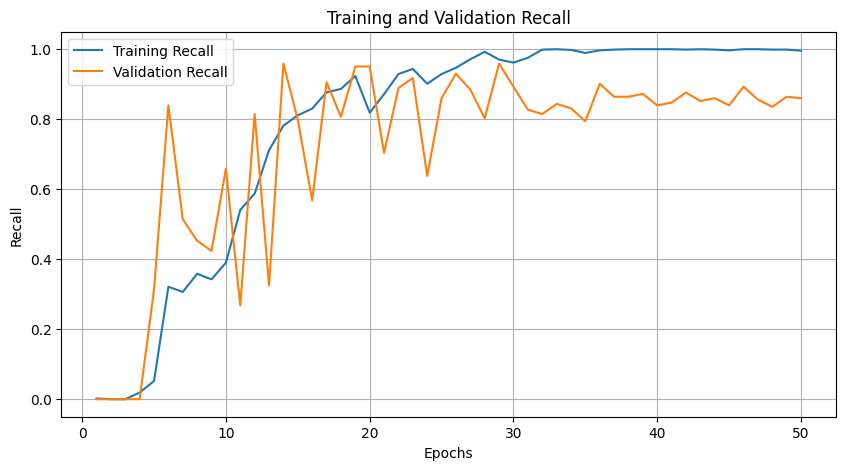

In [6]:
# Plot Recall
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_rec, label='Training Recall')
plt.plot(epochs, val_rec, label='Validation Recall')
plt.title('Training and Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)
plt.show()

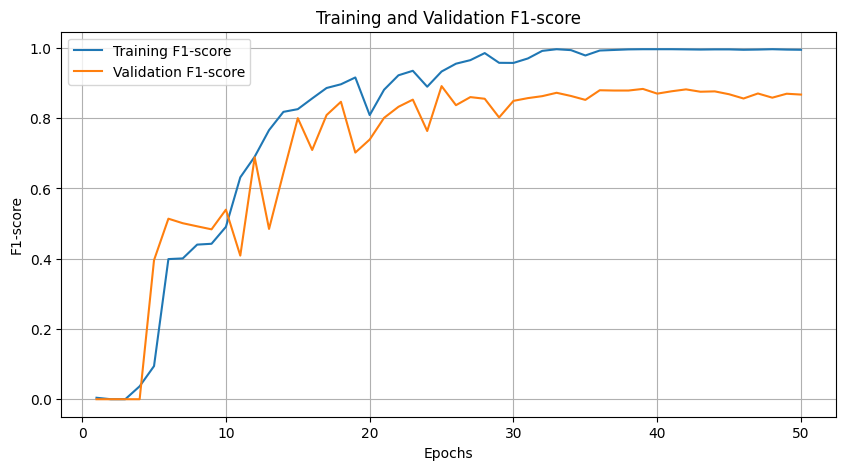

In [7]:
# Plot F1-score
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_f1, label='Training F1-score')
plt.plot(epochs, val_f1, label='Validation F1-score')
plt.title('Training and Validation F1-score')
plt.xlabel('Epochs')
plt.ylabel('F1-score')
plt.legend()
plt.grid(True)
plt.show()